In [366]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import math
from datetime import datetime, timedelta
import time

In [367]:
FILE_PATH = "data.xlsx"
NGAY_BAT_DAU_THI = datetime(2026, 2, 2) 
SO_NGAY_THI_MUC_TIEU = 25
GIO_THI_MAP = {1: "08:30", 2: "13:00", 3: "15:30"}

In [368]:
file_path = "data.xlsx"
df_hp = pd.read_excel(file_path, sheet_name="DS Hocphan")
df_sv = pd.read_excel(file_path, sheet_name="DS SV - masked")

In [369]:
# Tiền xử lí dữ liệu 
df_hp = df_hp.dropna(subset=["Mã học phần", "Mã LHP"])
df_sv = df_sv.dropna(subset=["MHP", "MSV"])

for col in ["Mã học phần", "Mã LHP"]:
    df_hp[col] = df_hp[col].astype(str).str.strip().str.upper()

for col in ["MHP", "MSV"]:
    df_sv[col] = df_sv[col].astype(str).str.strip().str.upper()

# Tách mã học phần gốc 
df_hp["HP_GOC"] = df_hp["Mã học phần"].str.extract(r"^([A-Z0-9]+)")
df_sv["HP_GOC"] = df_sv["MHP"].str.extract(r"^([A-Z0-9]+)")

hoc_phan = df_hp["HP_GOC"].unique().tolist()

In [370]:
df_hp.head(3)

,Mã LHP,Mã học phần,Mã môn thi,Số tín chỉ,Hình thức thi,HP_GOC
0,BIO1053E 1 CLCCNSH,BIO1053E,BIO1053E,3.0,Trắc nghiệm,BIO1053E
1,BIO1053E 2 CLCCNSH,BIO1053E,BIO1053E\n,3.0,Trắc nghiệm,BIO1053E
2,BIO1053E 3 CLCCNSH,BIO1053E,BIO1053E\n,3.0,Trắc nghiệm,BIO1053E


In [371]:
df_sv.head(3)

,MSV,MHP,Tên học phần,HP_GOC
0,19001449,GEO3265,Đánh giá đất và Quy hoạch sử dụng đất đai,GEO3265
1,20001231,GEO3265,Đánh giá đất và Quy hoạch sử dụng đất đai,GEO3265
2,20001235,GEO3265,Đánh giá đất và Quy hoạch sử dụng đất đai,GEO3265


In [372]:
# Lấy tên môn học theo mã học phần gốc 
cot_ten = None
for c in ["Tên học phần", "Tên môn", "Ten hoc phan"]:
    if c in df_sv.columns:
        cot_ten = c
        break

if cot_ten:
    ten_mon = (
        df_sv
        .dropna(subset=["HP_GOC", cot_ten])
        .drop_duplicates("HP_GOC")
        .set_index("HP_GOC")[cot_ten]
        .to_dict()
    )
else:
    print("Không tìm thấy cột tên môn trong DS SV - masked")
    ten_mon = {}

# Số tín chỉ 
so_tin_chi = df_hp.drop_duplicates("HP_GOC").set_index("HP_GOC")["Số tín chỉ"].to_dict()

# Sinh viên theo học phần gốc
sv_theo_hp = defaultdict(set)
for _, r in df_sv.iterrows():
    sv_theo_hp[r["HP_GOC"]].add(r["MSV"])

# Hình thức thi 
hinh_thuc = df_hp.drop_duplicates("HP_GOC").set_index("HP_GOC")["Hình thức thi"].to_dict()


# Khoa lấy ra 3 kí tự đầu 
khoa = {hp: hp[:3] for hp in hoc_phan}

In [373]:
print(so_tin_chi)
print(sv_theo_hp)
print(hinh_thuc)
print(khoa)

{'BIO1053E': 3.0, 'BIO2044': 3.0, 'BIO2045': 2.0, 'BIO2045E': 2.0, 'BIO2088': 3.0, 'BIO2089': 3.0, 'BIO2100': 3.0, 'BIO2127': 3.0, 'BIO2201': 3.0, 'BIO2202': 3.0, 'BIO2204': 3.0, 'BIO2206': 3.0, 'BIO2215E': 3.0, 'BIO2221': 3.0, 'BIO2222': 3.0, 'BIO2400E': 3.0, 'BIO2403E': 3.0, 'BIO2405E': 3.0, 'BIO2504': 3.0, 'BIO2516': 2.0, 'BIO2800': 3.0, 'BIO3178': 3.0, 'BIO3182': 3.0, 'BIO3190': 3.0, 'BIO3191': 4.0, 'BIO3193': 2.0, 'BIO3200': 4.0, 'BIO3201': 3.0, 'BIO3202': 3.0, 'BIO3227E': 3.0, 'BIO3252': 3.0, 'BIO3252E': 3.0, 'BIO3257': 3.0, 'BIO3258': 3.0, 'BIO3258E': 3.0, 'BIO3262': 3.0, 'BIO3263': 3.0, 'BIO3302': 3.0, 'BIO3302E': 3.0, 'BIO3303': 3.0, 'BIO3304': 3.0, 'BIO3356': 2.0, 'BIO3370E': 3.0, 'BIO3373': 4.0, 'BIO3377': 3.0, 'BIO3401E': 4.0, 'BIO3403E': 4.0, 'BIO3405E': 3.0, 'BIO3444': 3.0, 'BIO3504': 5.0, 'BIO3701': 3.0, 'BIO3706': 3.0, 'BIO3707': 3.0, 'BIO3802E': 3.0, 'BIO3803E': 3.0, 'BIO4074E': 2.0, 'BIO4076': 2.0, 'CHE1048': 2.0, 'CHE1052': 3.0, 'CHE1055': 4.0, 'CHE1057': 3.0, 'CHE10

In [374]:
# Danh sách các ngày thi từ 2-6
slots = []
danh_sach_ngay_thi = []
curr_date = NGAY_BAT_DAU_THI
while len(danh_sach_ngay_thi) < SO_NGAY_THI_MUC_TIEU:
    if curr_date.weekday() < 5:
        danh_sach_ngay_thi.append(curr_date)
        for ca in [1, 2, 3]:
            slots.append((curr_date, ca))
    curr_date += timedelta(days=1)

In [375]:
# Ma trận xung đột sinh viên 
xung_dot = defaultdict(set)

for i in range(len(hoc_phan)):
    for j in range(i+1, len(hoc_phan)):
        h1, h2 = hoc_phan[i], hoc_phan[j]
        if len(sv_theo_hp[h1] & sv_theo_hp[h2]) > 0:
            xung_dot[h1].add(h2)
            xung_dot[h2].add(h1)


In [376]:
print(xung_dot)

defaultdict(<class 'set'>, {'BIO1053E': {'BIO2206', 'BIO3444', 'BIO3182', 'CHE1080', 'BIO2516', 'BIO2127', 'GEO1050', 'BIO3302E', 'POL1001', 'MAT1091', 'BIO2045E', 'PHY1103', 'CHE1069', 'BIO3178', 'BIO2400E', 'CHE1081', 'MAT1101', 'BIO2215E', 'HIS1001', 'BIO2403E', 'CHE1057', 'BIO3803E', 'BIO2100', 'BIO2800', 'MAT1192', 'BIO3356', 'MAT1090', 'PHI1002', 'BIO3802E'}, 'BIO2045E': {'MAT1060', 'BIO3182', 'CHE1080', 'GEO1050', 'BIO2127', 'BIO3252', 'BIO3302E', 'POL1001', 'MAT1091', 'PHY1103', 'CHE1069', 'BIO3178', 'BIO2400E', 'CHE1081', 'MAT1101', 'HIS1001', 'BIO2403E', 'FLF1107', 'CHE1057', 'BIO3803E', 'MAT1192', 'BIO3356', 'PHI1002', 'BIO1053E', 'BIO3802E'}, 'BIO2100': {'BIO2206', 'MAT1060', 'BIO2201', 'BIO3182', 'BIO2221', 'CHE1080', 'BIO3201', 'BIO3257', 'BIO3303', 'GEO1050', 'BIO3252', 'BIO3200', 'BIO3701', 'POL1001', 'MAT1091', 'BIO2045', 'PHY1103', 'CHE1069', 'BIO3304', 'BIO2400E', 'CHE1081', 'BIO3258', 'MAT1101', 'HIS1001', 'CHE1057', 'BIO2504', 'BIO3803E', 'PHY1100', 'BIO3302', 'BIO

In [377]:
# Ràng buộc cứng 
lich_thi = {}

def hard_conflict(hp, ngay, ca):
    # SV không thi trùng ca
    for hp_khac in xung_dot[hp]:
        if hp_khac in lich_thi and lich_thi[hp_khac] == (ngay, ca):
            return True
    # Cùng khoa không thi cùng ca
    for hp_khac, (n, c) in lich_thi.items():
        if n == ngay and c == ca and khoa[hp] == khoa[hp_khac]:
            return True
    return False

# Ràng buộc mềm: Tính toán điểm phạt để tối ưu hóa lịch thi cho sinh viên
def soft_penalty(hp, ngay, ca):
    penalty = 0
    idx_ngay = danh_sach_ngay_thi.index(ngay)
    
    for sv in sv_theo_hp[hp]:
        # Truy xuất các môn đã xếp của sinh viên để tính khoảng cách giữa các môn thi
        lich_sv = [lich_thi[h] for h in xung_dot[hp] if h in lich_thi and sv in sv_theo_hp[h]]
        
        for n_cu, c_cu in lich_sv:
            idx_cu = danh_sach_ngay_thi.index(n_cu)
            khoang_cach_ca = abs((idx_ngay * 3 + ca) - (idx_cu * 3 + c_cu))
            
            # Một sinh viên không thi 2 ca liên tiếp 
            # Phạt cực nặng (100đ) nếu khoảng cách ca <= 1 (thi liên tiếp hoặc trùng ca)
            if khoang_cach_ca <= 1:
                penalty += 100 
            
            # Tránh thi 3 ngày liên tục
            # Khoảng cách càng nhỏ (dưới 2 ngày xấp xỉ 6 ca), penalty càng cao
            elif khoang_cach_ca < 6:
                # Công thức (6 - d) * 5 giúp dàn đều sinh viên ra các mốc xa hơn 2 ngày
                penalty += (6 - khoang_cach_ca) * 5
    
    # Môn >= 3 tín chỉ ưu tiên tránh ca cuối 
    # Nếu là môn nặng mà xếp vào ca chiều muộn thì cộng thêm điểm phạt (2đ)
    if so_tin_chi.get(hp, 0) >= 3 and ca == 3: 
        penalty += 2
        
    return penalty

## Thuật toán tham lam

In [378]:


# Thuật toán tham lam
# Ưu tiên các môn có nhiều xung đột xếp trước
hoc_phan_sorted = sorted(hoc_phan, key=lambda x: len(xung_dot[x]), reverse=True)
start_time = time.perf_counter()
for hp in hoc_phan_sorted:
    best_slot = None
    min_penalty = float('inf')
    
    for ngay, ca in slots:
        # Kiểm tra Ràng buộc cứng
        if not hard_conflict(hp, ngay, ca):
            # Tính toán tổng vi phạm Ràng buộc mềm tại slot này
            p = soft_penalty(hp, ngay, ca)
            
            # Chọn ca thi có điểm phạt thấp nhất (Thỏa mãn tốt nhất các ràng buộc mềm)
            if p < min_penalty:
                min_penalty = p
                best_slot = (ngay, ca)
    
    if best_slot:
        lich_thi[hp] = best_slot
    else:
        print(f"Không thể xếp lịch cho: {hp}")
end_time = time.perf_counter() 


In [379]:
print(f"Thời gian xếp lịch của thuật toán tham lam: {end_time - start_time:.4f} giây")

Thời gian xếp lịch của thuật toán tham lam: 9.0802 giây


In [380]:
# giả sử danh sách 100 phòng, mỗi phòng tối đa 30 chỗ
SUC_CHUA_CO_DINH = 30
danh_sach_phong = [f"P{i:03}" for i in range(1, 101)]

phong_da_dung_theo_slot = defaultdict(set)
ds_phong_hp = {}

hoc_phan_theo_slot = defaultdict(list)
for hp, slot in lich_thi.items():
    hoc_phan_theo_slot[slot].append(hp)

for slot, hps in hoc_phan_theo_slot.items():
    # Lấy danh sách các phòng còn trống trong slot này ngay từ đầu
    phong_trong = [p for p in danh_sach_phong if p not in phong_da_dung_theo_slot[slot]]
    
    # Sắp xếp môn đông sinh viên xử lý trước
    hps_sorted = sorted(hps, key=lambda x: len(sv_theo_hp[x]), reverse=True)
    
    for hp in hps_sorted:
        total_sv = len(sv_theo_hp[hp])
        so_phong_can = math.ceil(total_sv / SUC_CHUA_CO_DINH)
        
        # Lấy số phòng cần thiết từ danh sách phòng trống đã lấy ở trên
        phong_duoc_chon = phong_trong[:so_phong_can]
        phong_trong = phong_trong[so_phong_can:] 
        
        # Đánh dấu vào set để đồng bộ dữ liệu (nếu cần dùng lại ở nơi khác)
        for p in phong_duoc_chon:
            phong_da_dung_theo_slot[slot].add(p)

        if len(phong_duoc_chon) < so_phong_can:
            print(f"CẢNH BÁO: Slot {slot} thiếu {so_phong_can - len(phong_duoc_chon)} phòng cho môn {hp}")

        phan_bo = []
        sv_con_lai = total_sv
        so_phong_thuc_te = len(phong_duoc_chon)
        
        if so_phong_thuc_te > 0: 
            for i, p in enumerate(phong_duoc_chon):
                so_sv_phong_nay = math.ceil(sv_con_lai / (so_phong_thuc_te - i))
                phan_bo.append(f"{p}({so_sv_phong_nay})")
                sv_con_lai -= so_sv_phong_nay
            
            ds_phong_hp[hp] = ", ".join(phan_bo)
        else:
            ds_phong_hp[hp] = "KHÔNG XẾP ĐƯỢC PHÒNG"

In [381]:
# kết quả chạy 
ket_qua = []
for hp in hoc_phan:
    if hp in lich_thi:
        ngay, ca = lich_thi[hp]
        chuoi_phong = ds_phong_hp.get(hp, "")
        
        ket_qua.append({
            "Mã học phần": hp,
            "Tên môn": ten_mon.get(hp, "N/A"),
            "Số tín chỉ": so_tin_chi.get(hp, 0),
            "Thứ": ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6"][ngay.weekday()],
            "Ngày thi": ngay.strftime("%d/%m/%Y"),
            "Giờ thi": GIO_THI_MAP[ca],
            "Số SV": len(sv_theo_hp[hp]),
            "Phòng thi": chuoi_phong, 
            "Hình thức": hinh_thuc.get(hp, "")
        })

df_final = pd.DataFrame(ket_qua)
df_final["_sort_date"] = pd.to_datetime(df_final["Ngày thi"], format="%d/%m/%Y")
df_final["_sort_ca"] = df_final["Giờ thi"]
df_final = df_final.sort_values(["_sort_date", "_sort_ca"]).drop(columns=["_sort_date", "_sort_ca"])

df_final.to_excel("lich_thi.xlsx", index=False)

In [382]:
dtf = pd.read_excel("lich_thi.xlsx")

In [383]:
dtf.head(5)

,Mã học phần,Tên môn,Số tín chỉ,Thứ,Ngày thi,Giờ thi,Số SV,Phòng thi,Hình thức
0,BIO3202,Động vật học động vật có xương sống,3,Thứ 2,02/02/2026,08:30,50,"P041(25), P042(25)",Trắc nghiệm
1,CHE3211,Hoá lý vô cơ,3,Thứ 2,02/02/2026,08:30,7,P044(7),Khác
2,EVS3307,Tin học ứng dụng trong môi trường,3,Thứ 2,02/02/2026,08:30,5,P046(5),Khác
3,GLO2210,Xác suất thống kê trong Khoa học Trái đất,3,Thứ 2,02/02/2026,08:30,71,"P038(24), P039(24), P040(23)",Viết
4,HMO3609,Dự báo thủy văn biển,3,Thứ 2,02/02/2026,08:30,4,P047(4),Vấn đáp


C:\Users\Admin\AppData\Local\Temp\ipykernel_20964\1991117050.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


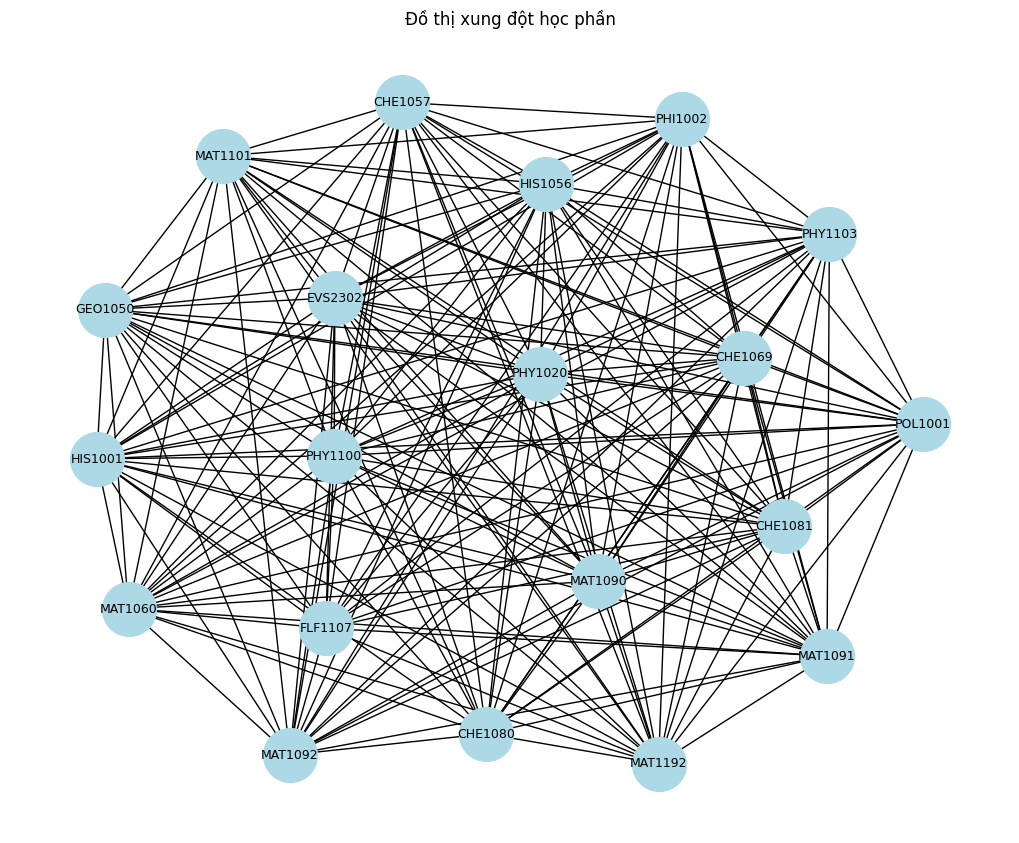

In [384]:
import networkx as nx
import matplotlib.pyplot as plt

top_hp = sorted(xung_dot.keys(), key=lambda x: len(xung_dot[x]), reverse=True)[:20]

G = nx.Graph()
for hp in top_hp:
    G.add_node(hp)

for hp in top_hp:
    for hp2 in xung_dot[hp]:
        if hp2 in top_hp:
            G.add_edge(hp, hp2)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=1500, font_size=9)
plt.title("Đồ thị xung đột học phần")
plt.tight_layout()
plt.savefig("do_thi_xung_dot.png", dpi=200)
plt.show()

In [385]:
CA_ORDER = ['08:30', '13:00', '15:30']
COLORS_CA = ['#5D85C1', '#7EB6D9', '#84A98C']
COLORS_TC = {2: '#5D85C1', 3: '#7EB6D9', 4: '#84A98C', 5: '#E57373'}

def prepare_data(df_final):
    df_plot = df_final.copy()
    df_plot['Ngay_DT'] = pd.to_datetime(df_plot['Ngày thi'], format="%d/%m/%Y")
    df_plot = df_plot.sort_values('Ngay_DT')
    df_plot['Ngay_Thang'] = df_plot['Ngay_DT'].dt.strftime('%d/%m')
    return df_plot

In [395]:
def export_do_thi_quan_ly_chung(df_final, ten_thuat_toan="THAM_LAM"):
    df_plot = df_final.copy()
    
    df_plot['Ngay_DT'] = pd.to_datetime(df_plot['Ngày thi'], format="%d/%m/%Y")
    df_plot = df_plot.sort_values('Ngay_DT')
    df_plot['Ngay_Thang'] = df_plot['Ngay_DT'].dt.strftime('%d/%m')
    
    def find_col(possible_names, default_name):
        for name in possible_names:
            if name in df_plot.columns:
                return name
        return default_name

    col_sv = find_col(['Số SV', 'Số lượng SV', 'Tổng số SV', 'Tổng số SV thực tế'], 'Số SV')
    col_phong = find_col(['Phòng thi', 'Phòng thi chi tiết', 'Chi tiết phòng (Sĩ số)', 'Phòng'], 'Phòng thi')
    col_gio = find_col(['Giờ thi', 'Giờ bắt đầu', 'Ca thi'], 'Giờ thi')

    metrics = [
        ('Lop_HP', "Lớp HP", lambda df: df.groupby(['Ngay_Thang', col_gio]).size()),
        ('Sinh_vien', "Sinh viên", lambda df: df.pivot_table(index='Ngay_Thang', columns=col_gio, values=col_sv, aggfunc='sum')),
        ('Phong_thi', "Phòng thi", lambda df: pd.DataFrame([
            {'Ngay_Thang': r['Ngay_Thang'], col_gio: r[col_gio]} 
            for _, r in df.iterrows() 
            for p in str(r[col_phong]).split(',') if p.strip() and p != 'nan'
        ]).groupby(['Ngay_Thang', col_gio]).size())
    ]

    for label_key, label_name, func in metrics:
        try:
            raw_data = func(df_plot)
            data = raw_data.unstack(fill_value=0) if label_key != 'Sinh_vien' else raw_data.fillna(0)
            data = data.reindex(index=df_plot['Ngay_Thang'].unique(), columns=CA_ORDER, fill_value=0)
            
            plt.figure(figsize=(22, 8))
            is_phong = (label_key == 'Phong_thi')
            ax = data.plot(kind='bar', stacked=not is_phong, color=COLORS_CA, width=0.85, ax=plt.gca(), edgecolor='white')

            if is_phong:
                for p in ax.patches:
                    h = p.get_height()
                    if h > 0:
                        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width()/2., h),
                                    ha='center', va='bottom', fontsize=10, fontweight='bold')
                plt.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Giới hạn 100 phòng/ca')
                plt.title(f'THỐNG KÊ PHÒNG THI THEO CA ({ten_thuat_toan})', fontsize=16, fontweight='bold', color='darkred')
            else:
                totals = data.sum(axis=1)
                for i, total in enumerate(totals):
                    if total > 0:
                        ax.annotate(f'{int(total)}', (i, total),
                                    ha='center', va='bottom', fontsize=11, fontweight='bold')
                plt.title(f'TỔNG QUY MÔ {label_name.upper()} THEO NGÀY ({ten_thuat_toan})', fontsize=16, fontweight='bold')

            plt.ylabel(f'Số lượng {label_name}')
            plt.legend(title='Ca thi', bbox_to_anchor=(1.01, 1), loc='upper left')
            plt.xticks(rotation=45)
            plt.grid(axis='y', linestyle=':', alpha=0.6)
            plt.tight_layout()
            
            plt.savefig(f'{ten_thuat_toan.lower()}_thong_ke_{label_key.lower()}.png', dpi=300)
            plt.show()

        except Exception as e:
            print(f"Lỗi khi vẽ biểu đồ {label_name} ({ten_thuat_toan}): {e}")

In [ ]:
from collections import defaultdict

def export_do_thi_on_tap_chung(df_final, df_sv, ten_thuat_toan="THAM_LAM"):
    hp_info = df_final.set_index('Mã học phần')[['Ngày thi', 'Giờ thi', 'Số tín chỉ']].to_dict('index')
    
    sv_paths = defaultdict(list)
    for _, row in df_sv.iterrows():
        mhp = row['HP_GOC']
        if mhp in hp_info:
            time_str = f"{hp_info[mhp]['Ngày thi']} {hp_info[mhp]['Giờ thi']}"
            sv_paths[row['MSV']].append({
                'time': pd.to_datetime(time_str, format="%d/%m/%Y %H:%M"),
                'tc': int(hp_info[mhp]['Số tín chỉ']) 
            })

    on_tap_records = []
    for msv, path in sv_paths.items():
        if len(path) > 1:
            path.sort(key=lambda x: x['time'])
            for i in range(len(path) - 1):
                diff_hours = (path[i+1]['time'] - path[i]['time']).total_seconds() / 3600
                num_ca = int(diff_hours // 4)
                on_tap_records.append({
                    'ca_nghi': num_ca,
                    'tc': path[i+1]['tc'],
                    'count_mon': len(path)
                })

    df_gap = pd.DataFrame(on_tap_records)
    if df_gap.empty:
        print(f"⚠ Không có dữ liệu để vẽ đồ thị ôn tập ({ten_thuat_toan})")
        return
    
    df_gap['tc'] = df_gap['tc'].astype(int)

    for suffix, nhom_label, condition in [
        ('it_mon', '≤ 6 môn', df_gap['count_mon'] <= 6),
        ('nhieu_mon', '> 6 môn', df_gap['count_mon'] > 6)
    ]:
        subset = df_gap[condition].copy()
        if subset.empty:
            continue
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
        fig.suptitle(
            f'PHÂN TÍCH THỜI GIAN ÔN TẬP ({ten_thuat_toan}) - NHÓM HỌC {nhom_label.upper()}',
            fontsize=18, fontweight='bold'
        )

        # Biểu đồ 1: chi tiết số ca nghỉ 
        pivot_gap = subset.groupby(['ca_nghi', 'tc']).size().unstack(fill_value=0).reindex(index=range(6), fill_value=0)
        colors = [COLORS_TC.get(c, COLORS_TC.get(float(c), 'gray')) for c in pivot_gap.columns]
        pivot_gap.plot(kind='bar', stacked=True, ax=ax1, color=colors, width=0.6)
        ax1.set_title("Chi tiết số ca nghỉ (0–5 ca)")

        for i, val in enumerate(pivot_gap.sum(axis=1)):
            if val > 0:
                ax1.text(i, val + 2, int(val), ha='center', fontweight='bold')

        # Biểu đồ 2: so sánh ôn tập ngắn/dài 
        subset['nhom_gap'] = subset['ca_nghi'].apply(lambda x: 'Ôn tập ngắn (≤ 5 ca)' if x <= 5 else 'Ôn tập dài (≥ 6 ca)')
        pivot_compare = subset.groupby(['nhom_gap', 'tc']).size().unstack(fill_value=0)
        pivot_compare = pivot_compare.reindex(['Ôn tập ngắn (≤ 5 ca)', 'Ôn tập dài (≥ 6 ca)'], fill_value=0)

        colors_compare = [COLORS_TC.get(c, COLORS_TC.get(float(c), 'gray')) for c in pivot_compare.columns]
        pivot_compare.plot(kind='bar', stacked=True, ax=ax2, color=colors_compare, width=0.4)

        total = pivot_compare.sum().sum()
        for i, val in enumerate(pivot_compare.sum(axis=1)):
            percent = (val / total) * 100 if total > 0 else 0
            ax2.text(i, val + total * 0.01, f"{int(val)} ({percent:.1f}%)",
                     ha='center', fontweight='bold', fontsize=12)

        plt.xticks(rotation=0)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f'{ten_thuat_toan.lower()}_thoi_gian_on_tap_{suffix}.png', dpi=300)
        plt.show()

In [398]:
def export_do_thi_tai_trong_ngay(df_final, df_sv, ten_thuat_toan="THAM LAM"):
    hp_ngay = df_final.set_index('Mã học phần')['Ngày thi'].to_dict()
    records = [
        {'MSV': r['MSV'], 'Ngay': hp_ngay[r['HP_GOC']]}
        for _, r in df_sv.iterrows()
        if r['HP_GOC'] in hp_ngay
    ]
    df_load = pd.DataFrame(records)
    load_counts = df_load.groupby(['MSV', 'Ngay']).size().value_counts().sort_index()

    plt.figure(figsize=(10, 6))

    if ten_thuat_toan.upper() == "DSATUR":
        colors = ['#90CAF9', '#F48FB1', '#CE93D8']   
    else:
        colors = ['#84A98C', '#E57373', '#FFD166']   

    bars = plt.bar(load_counts.index.astype(str), load_counts.values,
                   color=colors[:len(load_counts)], width=0.5)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + max(load_counts.values)*0.02,
                 f"{int(h)} SV", ha='center', fontweight='bold', fontsize=12)

    plt.title(
        f'THỐNG KÊ SỐ MÔN THI TRONG CÙNG 1 NGÀY CỦA SINH VIÊN ({ten_thuat_toan})',
        fontsize=14, fontweight='bold'
    )
    plt.xlabel('Số lượng môn thi/ngày')
    plt.ylabel('Số lượng sinh viên')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    file_name = f'thong_ke_tai_trong_ngay_{ten_thuat_toan.lower()}.png'
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Đã lưu đồ thị: {file_name}")

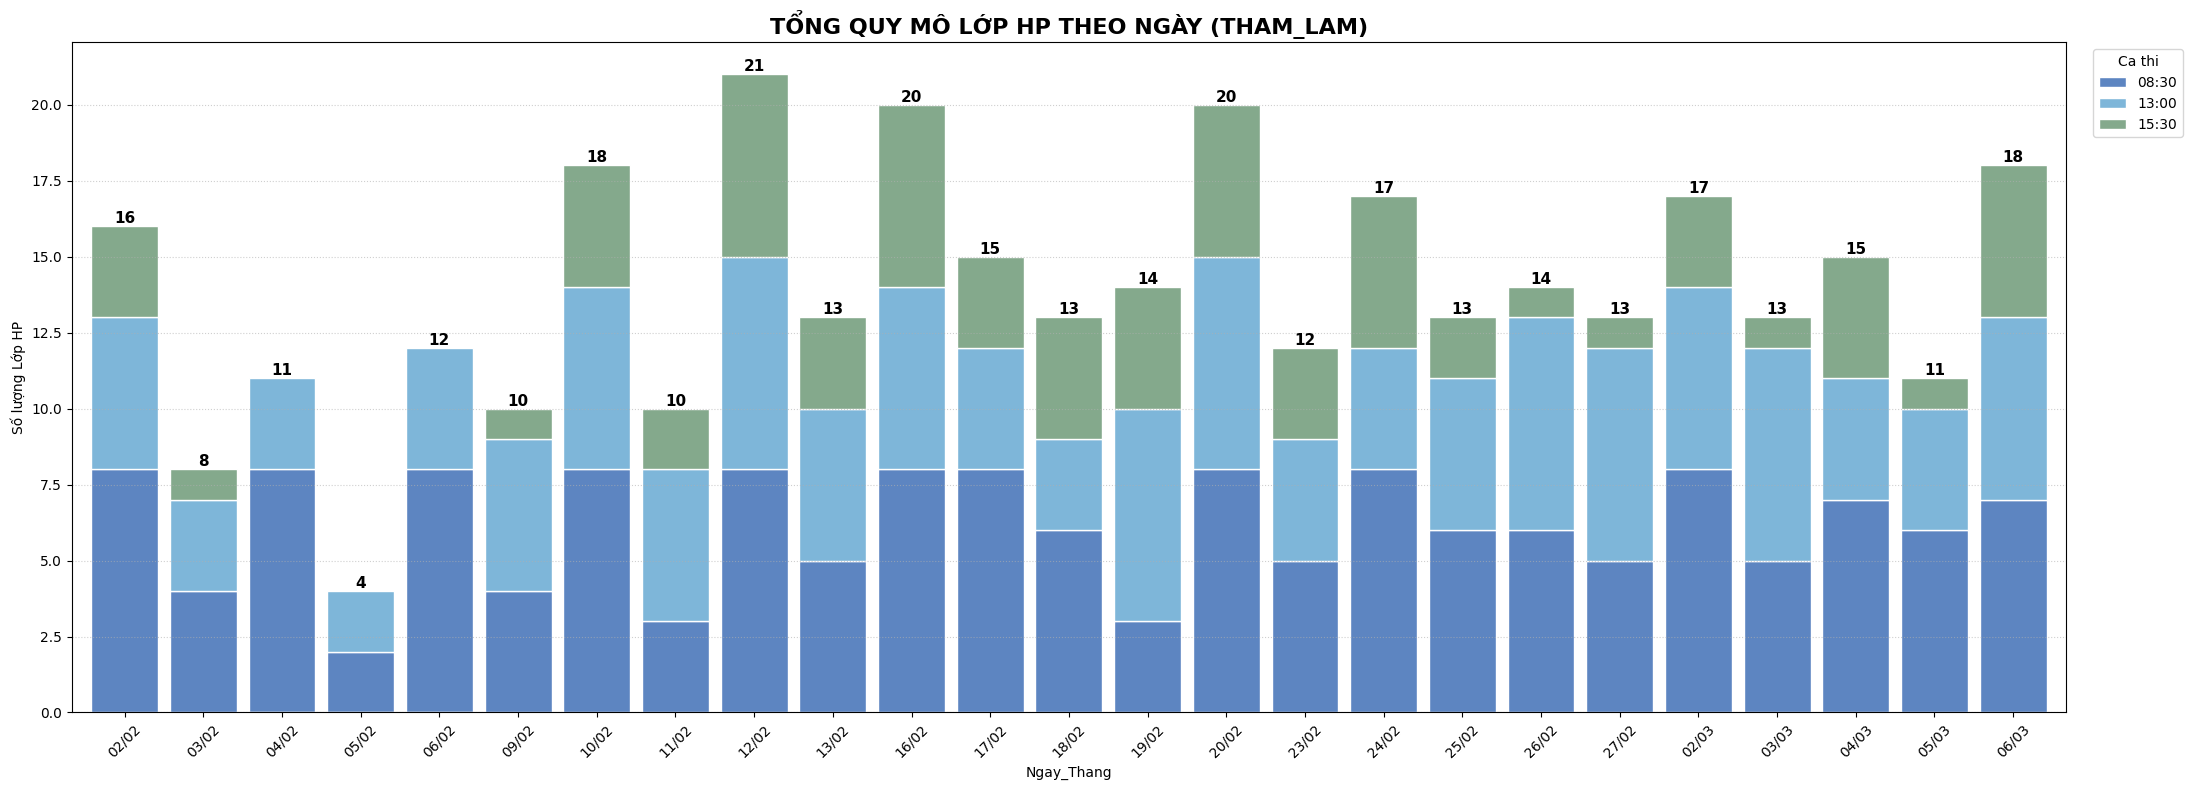

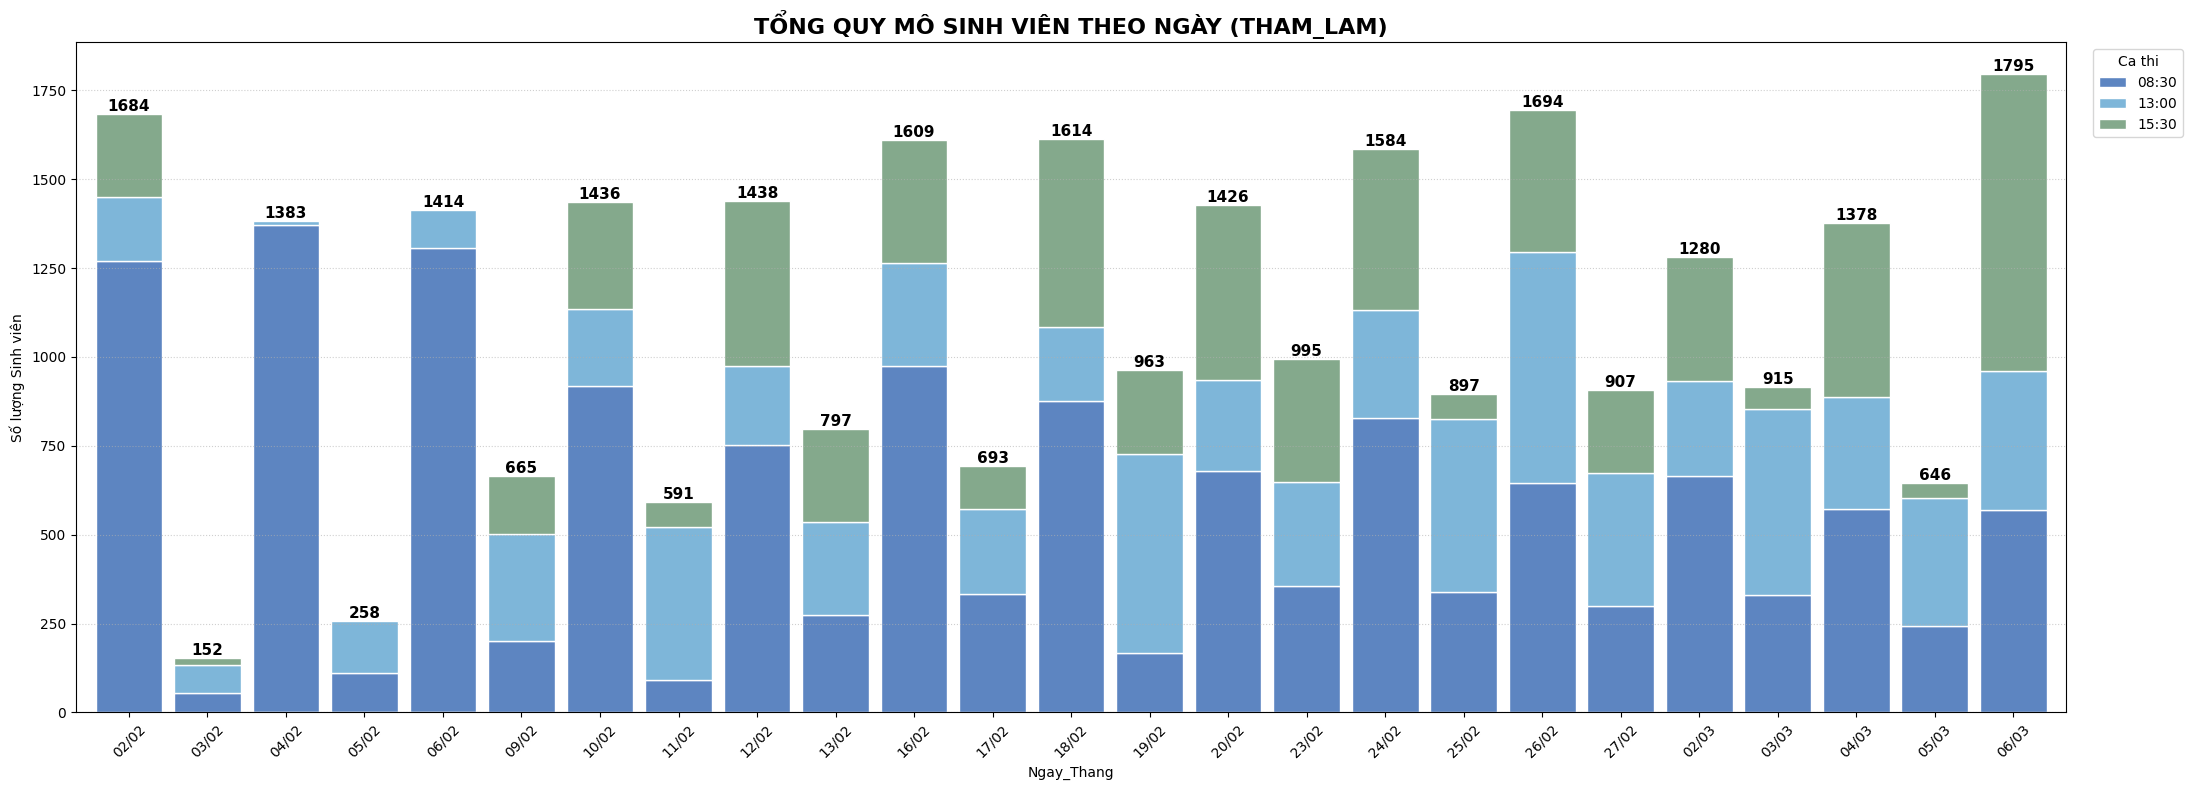

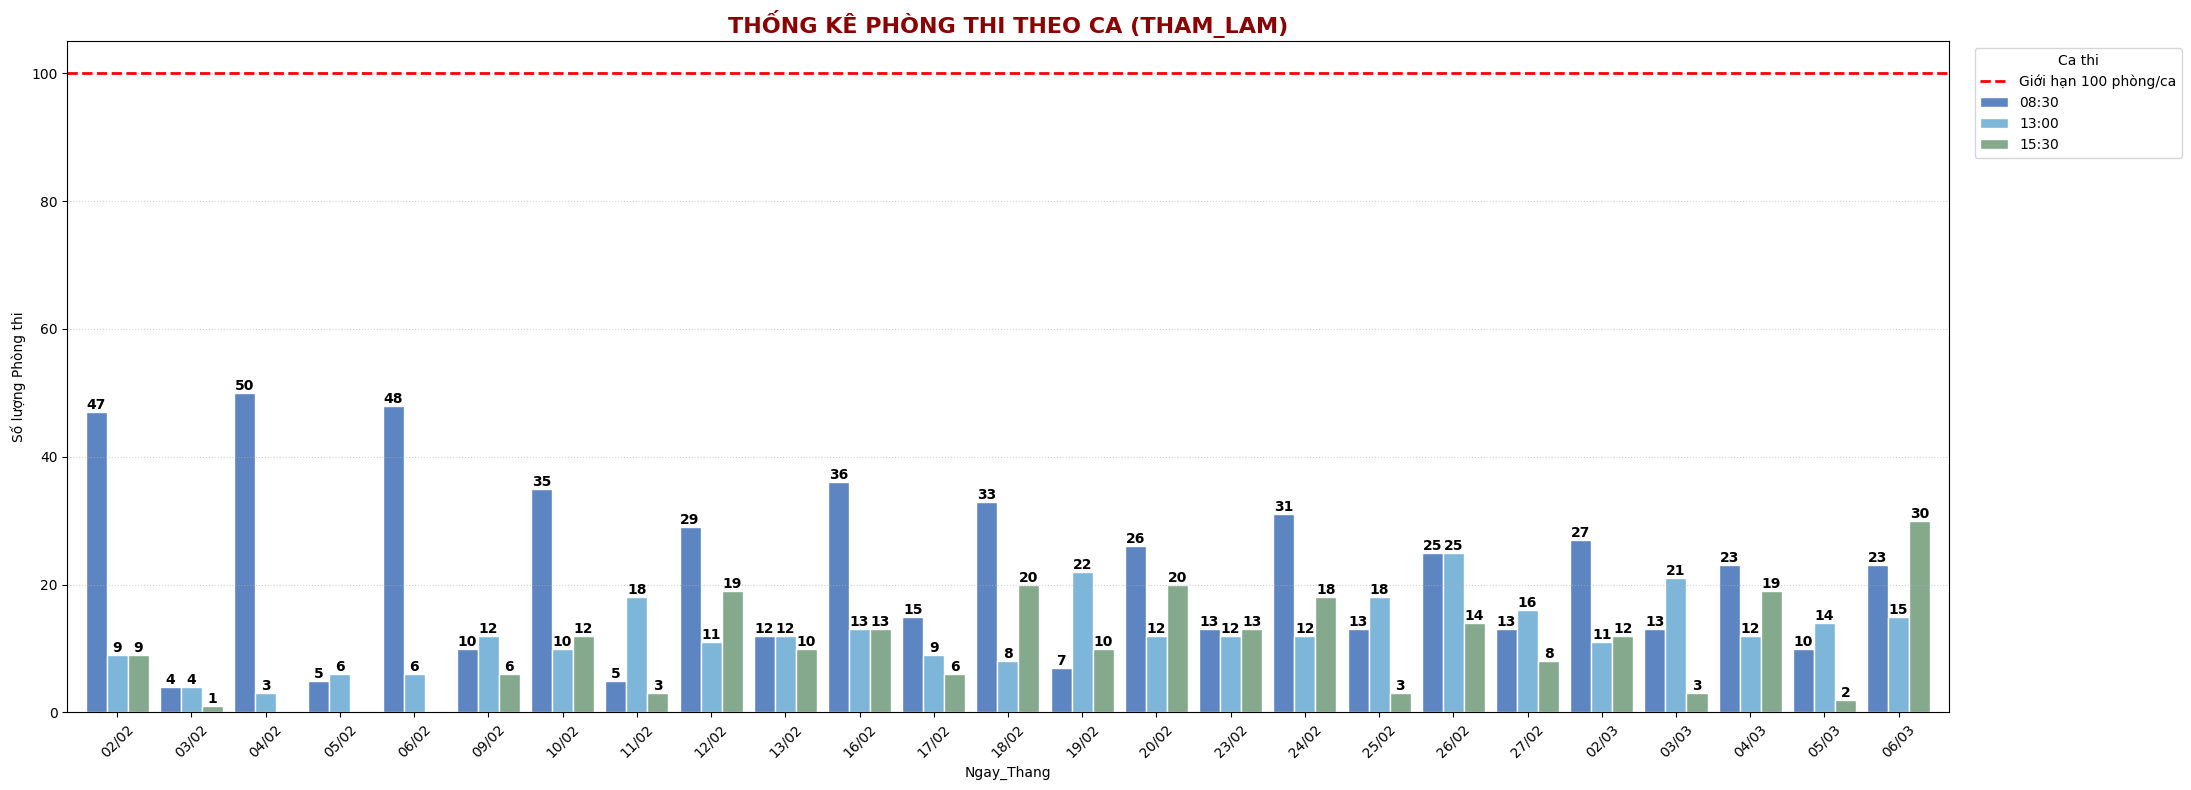

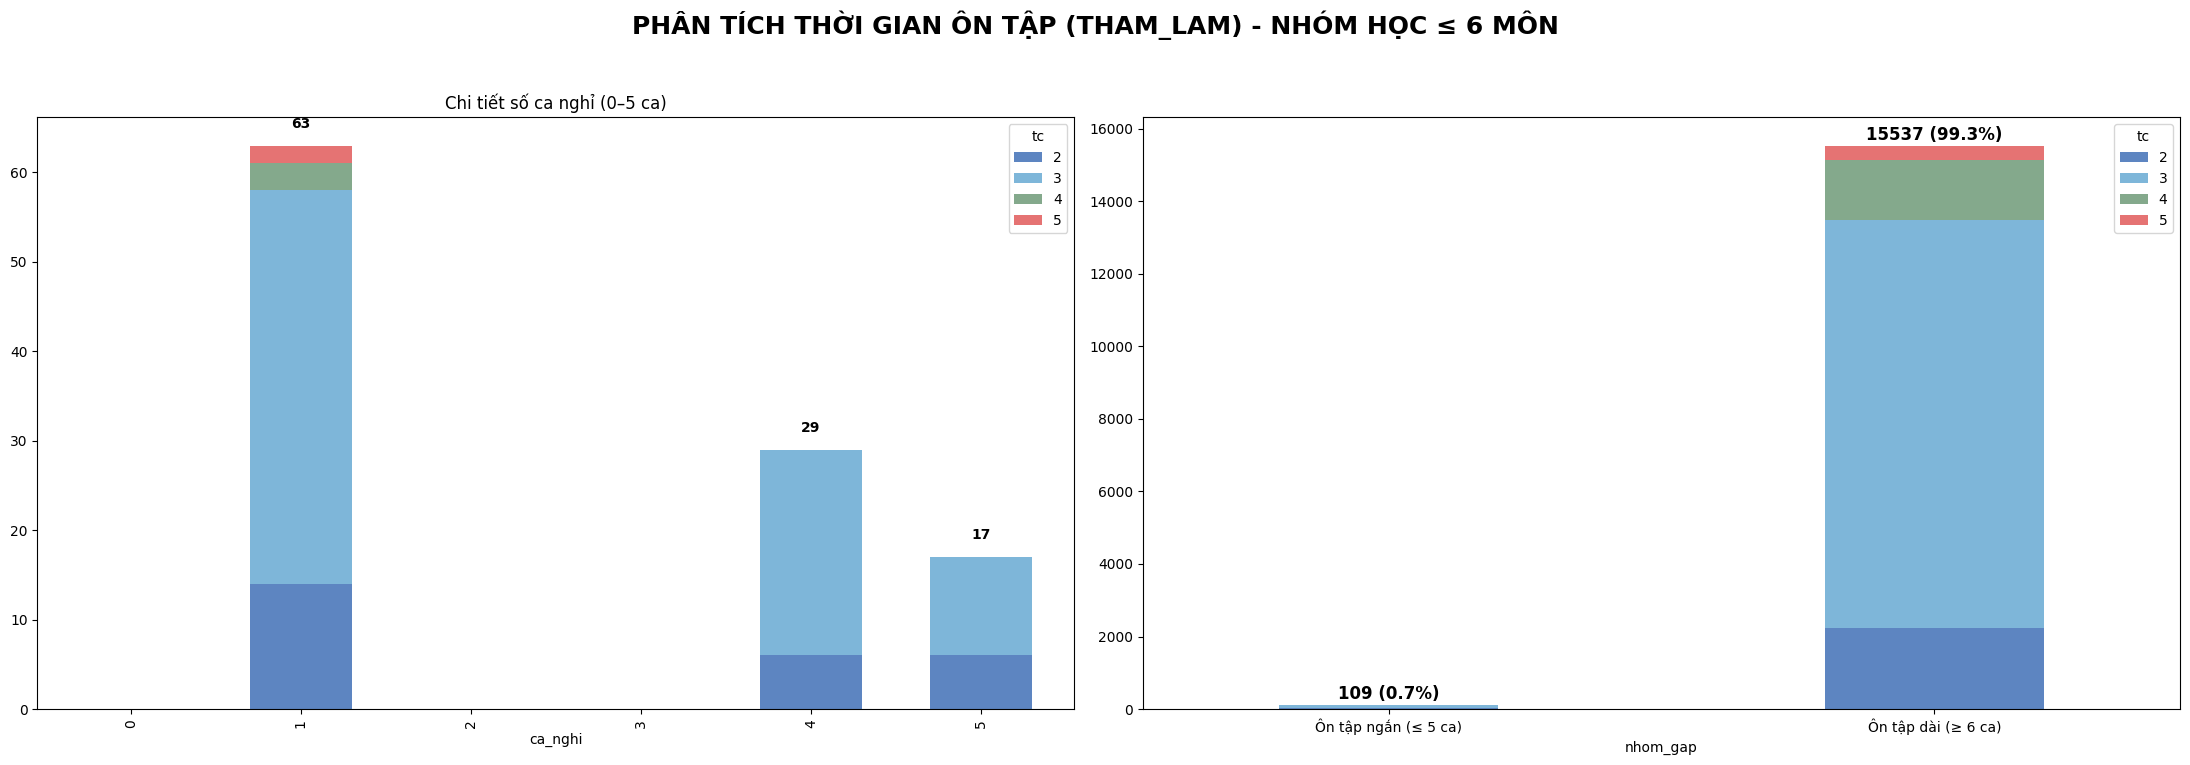

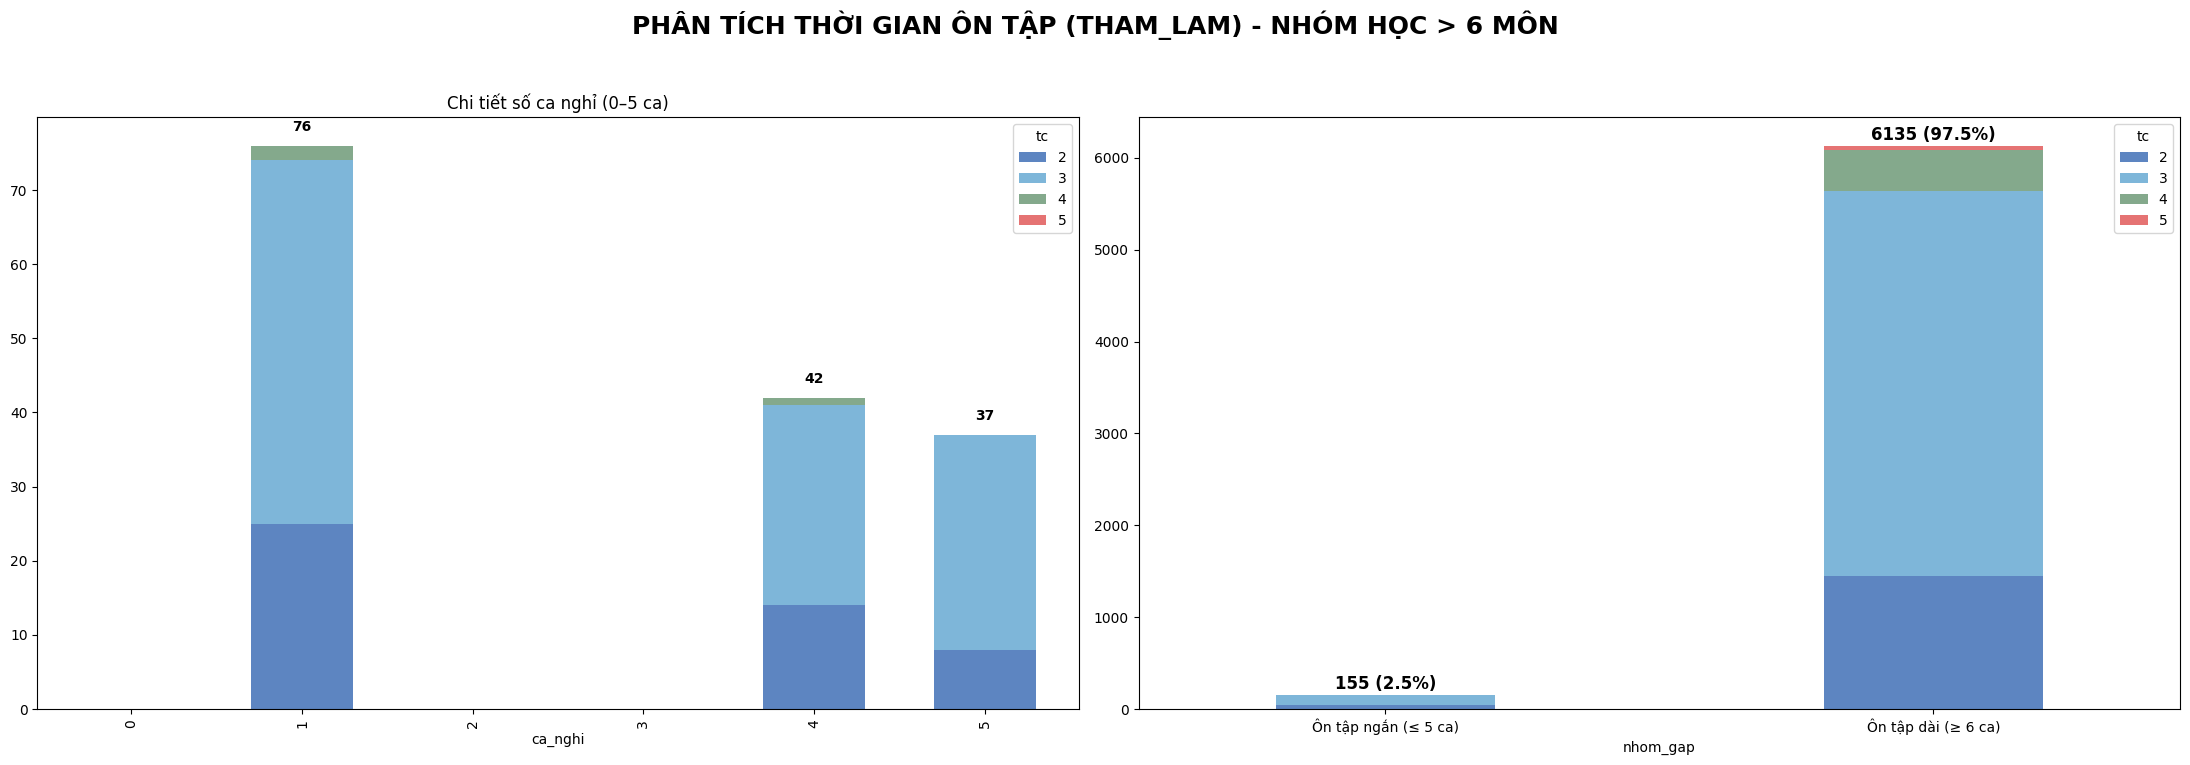

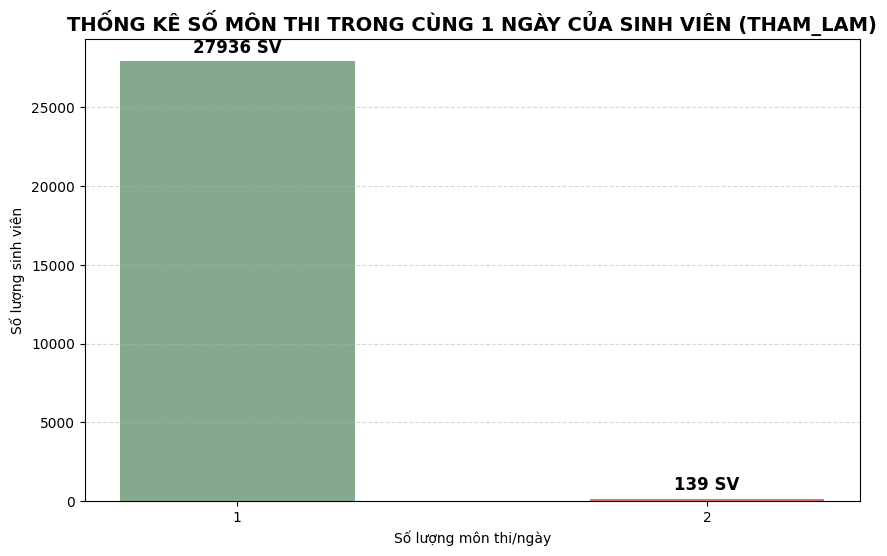

Đã lưu đồ thị: thong_ke_tai_trong_ngay_tham_lam.png


In [402]:
df_plot = prepare_data(df_final)
export_do_thi_quan_ly_chung(df_final, ten_thuat_toan="THAM_LAM")
export_do_thi_on_tap_chung(df_final, df_sv, ten_thuat_toan="THAM_LAM")
export_do_thi_tai_trong_ngay(df_final, df_sv, ten_thuat_toan="THAM_LAM")

## Thuật toán DSATUR

In [ ]:
import time

result_colors = {}          
degree = {hp: len(xung_dot[hp]) for hp in hoc_phan}
saturation = {hp: set() for hp in hoc_phan}  # lưu các màu lân cận đã dùng
chua_xep = set(hoc_phan)

sstart_time = time.perf_counter()

while chua_xep:
    # Chọn đỉnh có saturation lớn nhất, hòa thì chọn degree lớn nhất
    best_hp = max(
        chua_xep,
        key=lambda hp: (len(saturation[hp]), degree[hp])
    )

    # Tô màu: duyệt màu hợp lệ, chọn slot có penalty nhỏ nhất
    best_color = None
    best_slot = None
    min_penalty = float('inf')

    color = 0
    while color < len(slots):
        ngay, ca = slots[color]
        if not hard_conflict(best_hp, ngay, ca):
            p = soft_penalty(best_hp, ngay, ca)
            if p < min_penalty:
                min_penalty = p
                best_color = color
                best_slot = (ngay, ca)
        color += 1

    if best_color is None:
        print(f"Không tìm được slot hợp lệ cho {best_hp}")
        chua_xep.remove(best_hp)
        continue

    # Gán lịch
    result_colors[best_hp] = best_color
    lich_thi[best_hp] = best_slot

    # Cập nhật saturation cho các đỉnh kề chưa tô
    for nb in xung_dot[best_hp]:
        if nb in chua_xep:
            saturation[nb].add(best_color)

    chua_xep.remove(best_hp)

end_time = time.perf_counter()

print(f"Thời gian chạy DSATUR : {end_time - start_time:.6f} giây")

Thời gian chạy DSATUR : 26.292303 giây


In [ ]:

ket_qua_dsatur = []

for hp in hoc_phan:
    if hp in lich_thi:
        ngay, ca = lich_thi[hp]
        total_sv = len(sv_theo_hp[hp])
        
        # Lấy thông tin phòng thi đã phân bổ từ logic ds_phong_hp 
        chuoi_phong = ds_phong_hp.get(hp, "CHƯA PHÂN PHÒNG")
        
        ket_qua_dsatur.append({
            "Mã học phần": hp,
            "Tên môn học": ten_mon.get(hp, "N/A"),
            "Số tín chỉ": so_tin_chi.get(hp, 0),
            "Hình thức thi": hinh_thuc.get(hp, "Tự luận"),
            "Ngày thi": ngay.strftime("%d/%m/%Y"),
            "Thứ": ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ Nhật"][ngay.weekday()],
            "Ca thi": ca,
            "Giờ bắt đầu": GIO_THI_MAP.get(ca, "N/A"),
            "Tổng số SV": total_sv,
            "Số lượng phòng": math.ceil(total_sv / 30),
            "Chi tiết phòng (Sĩ số)": chuoi_phong
        })

df_dsatur = pd.DataFrame(ket_qua_dsatur)

df_dsatur['_temp_date'] = pd.to_datetime(df_dsatur['Ngày thi'], format='%d/%m/%Y')
df_dsatur = df_dsatur.sort_values(['_temp_date', 'Ca thi']).drop(columns=['_temp_date'])

df_dsatur.to_excel("lich_thi_dsatur.xlsx", index=False)

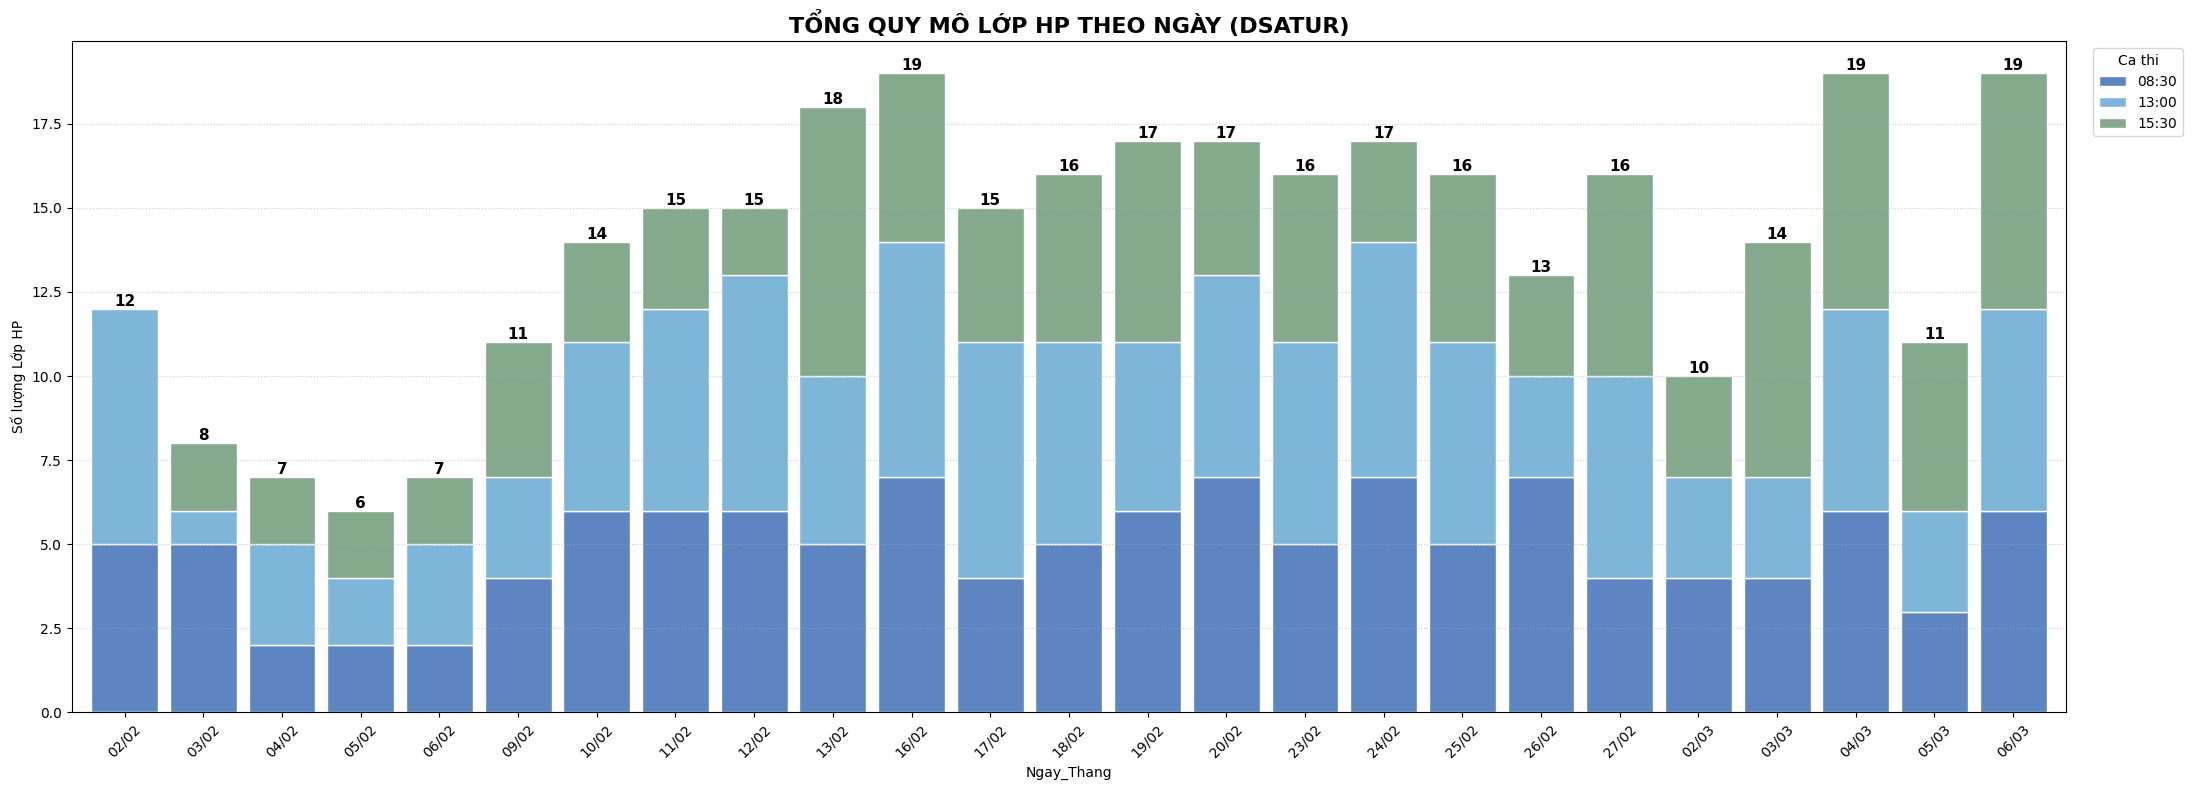

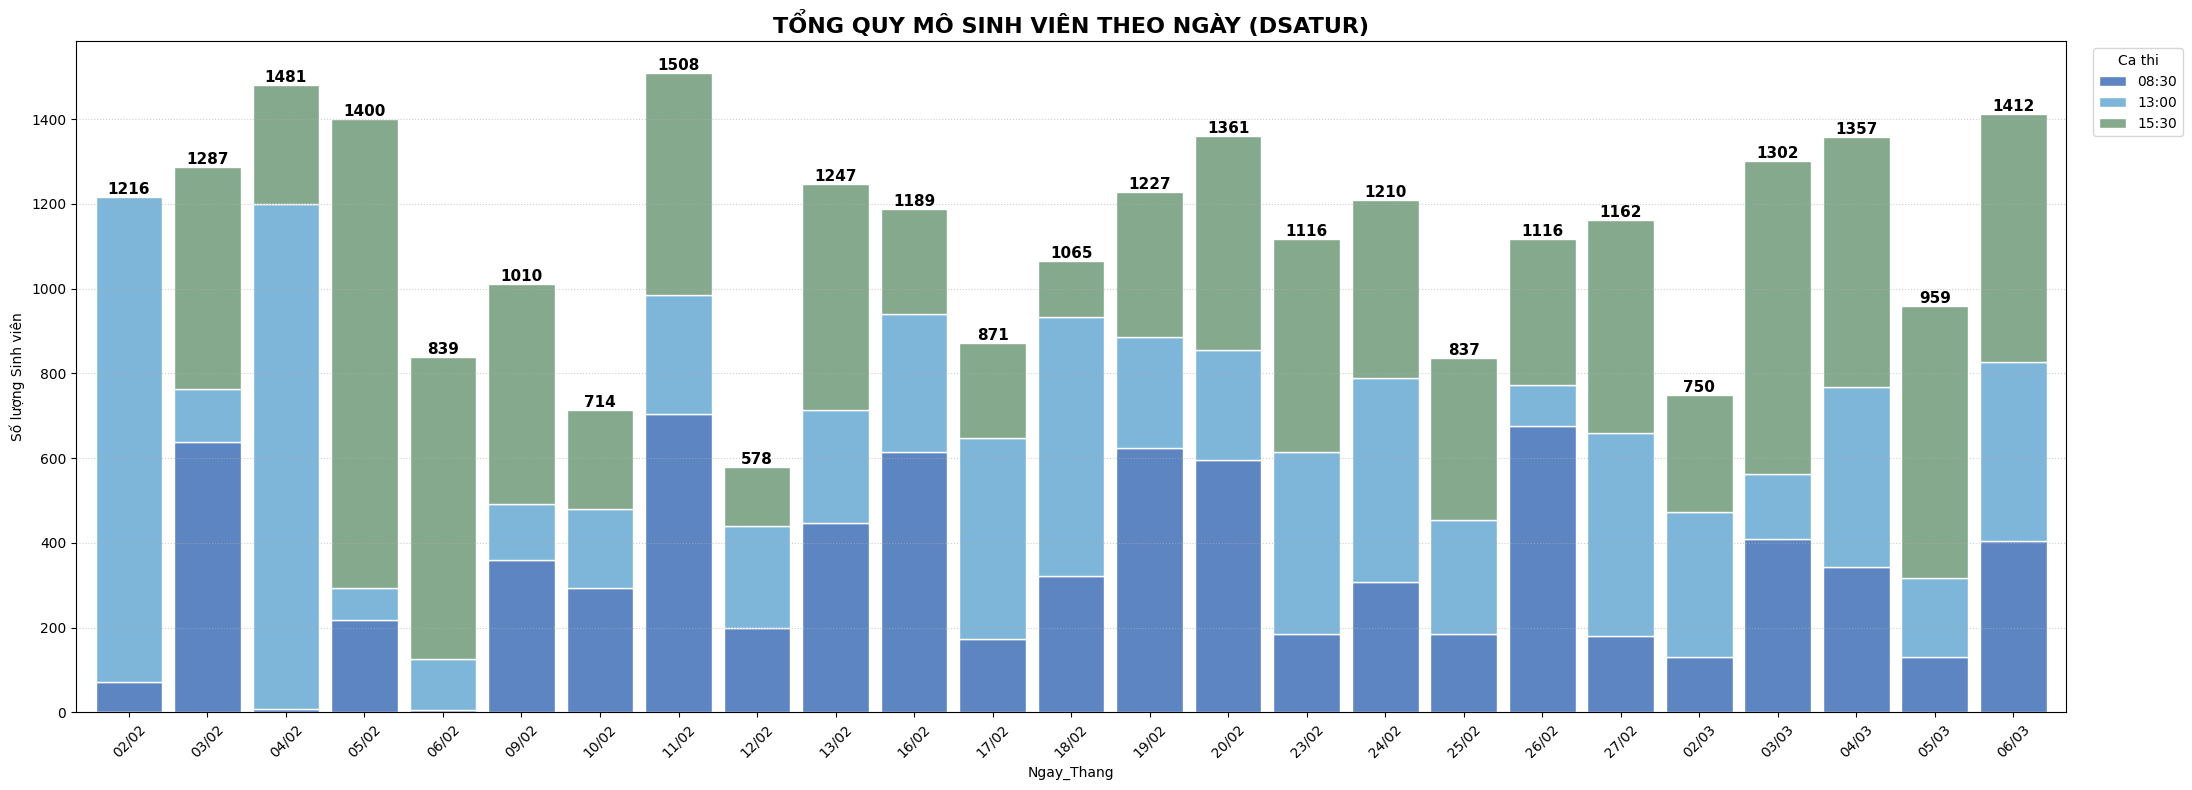

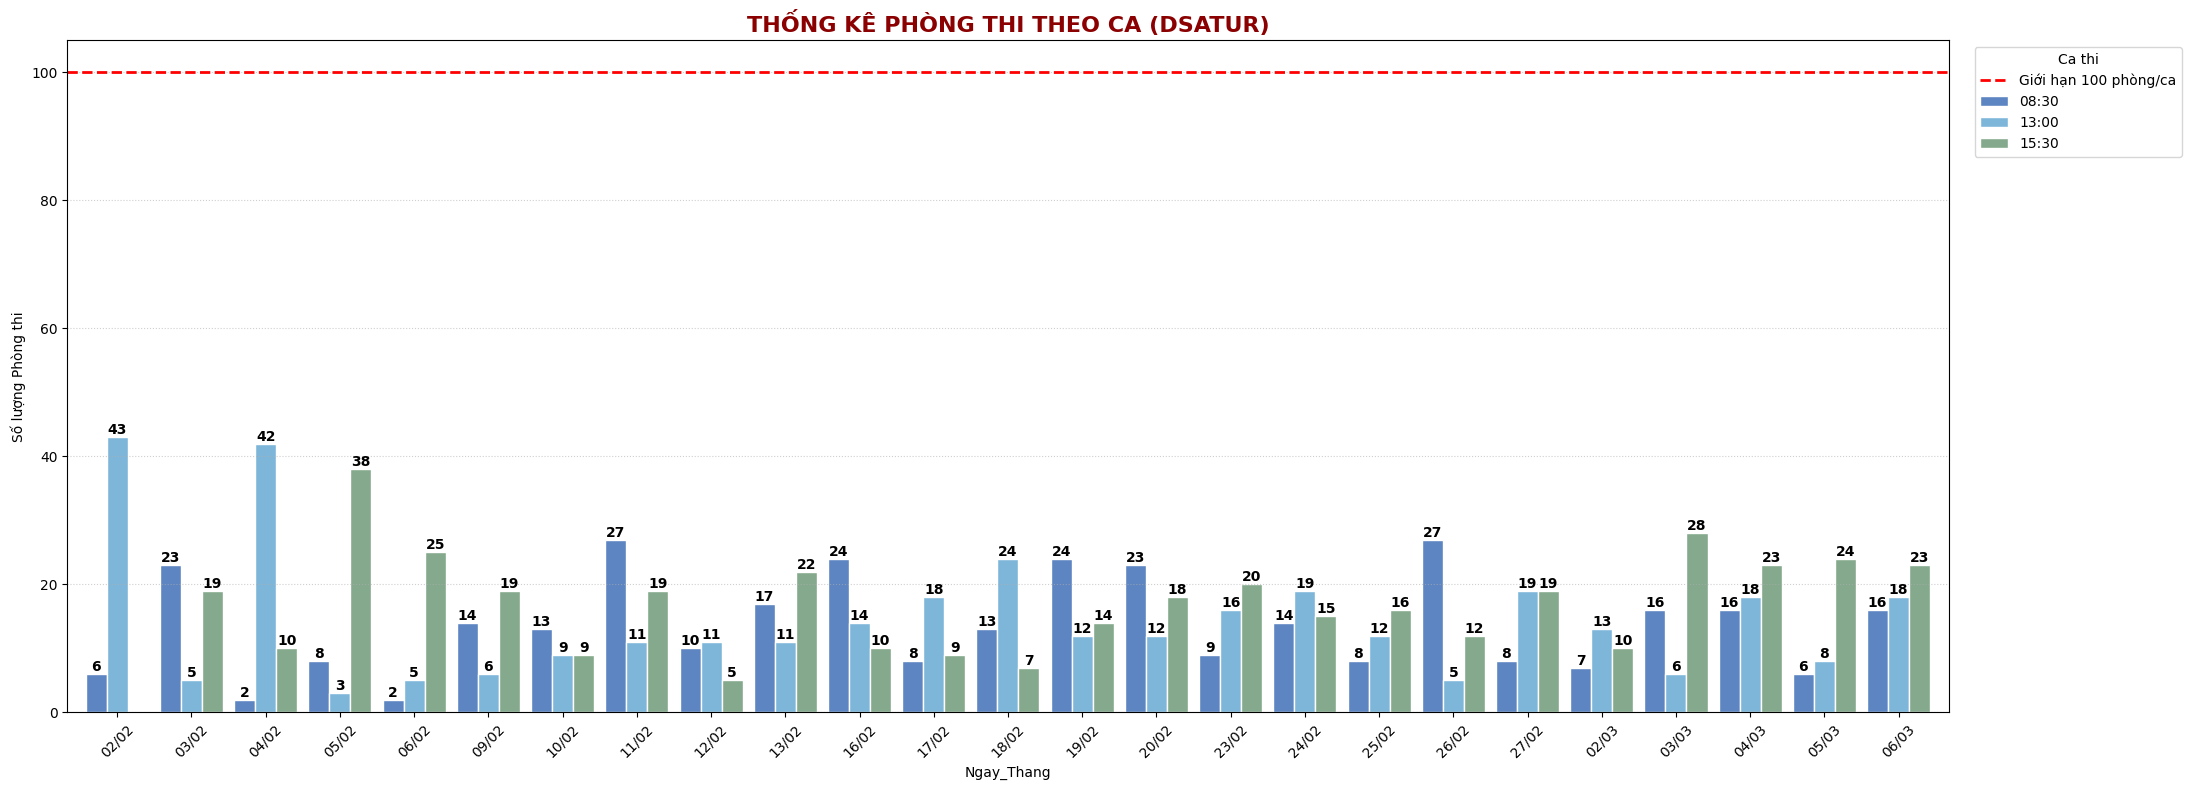

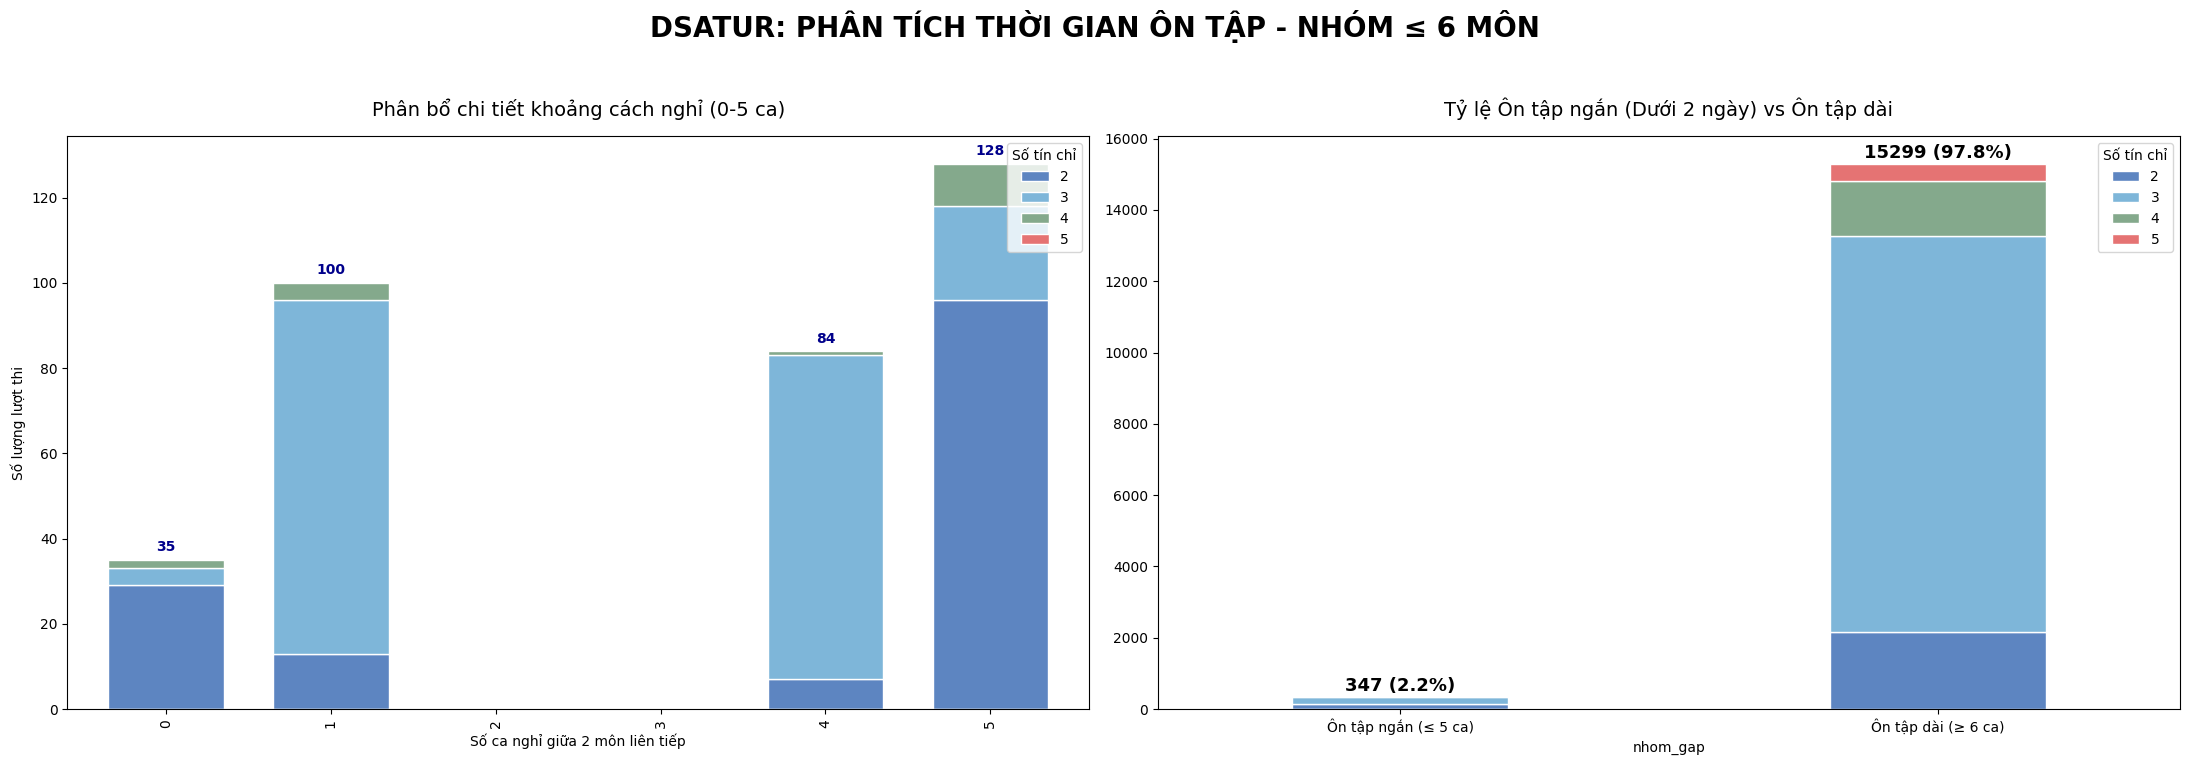

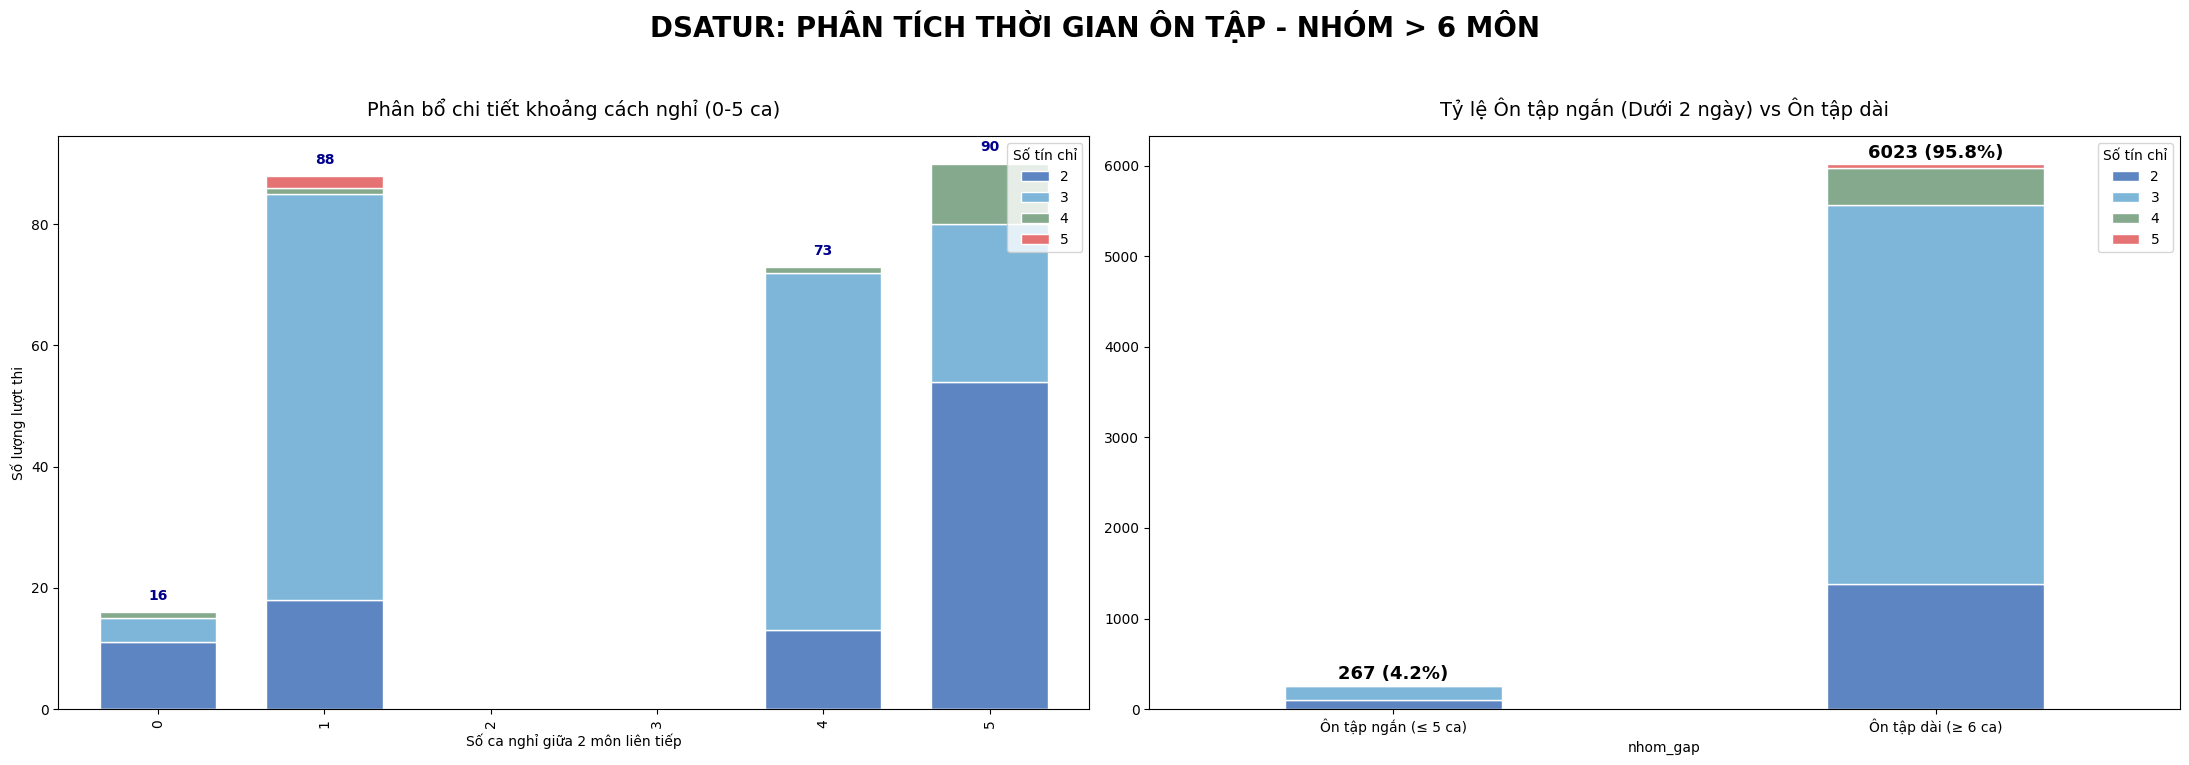

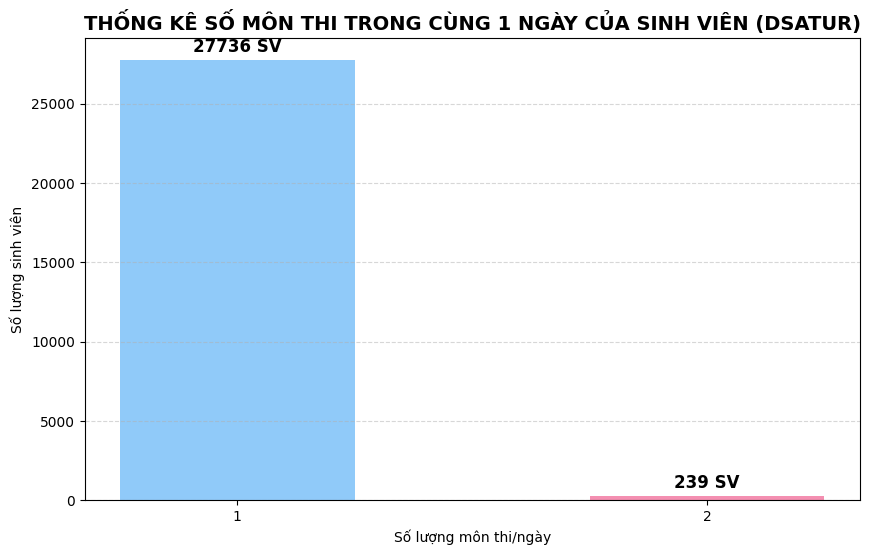

Đã lưu đồ thị: thong_ke_tai_trong_ngay_dsatur.png


In [ ]:
df_dsatur_final = pd.DataFrame(ket_qua_dsatur)

export_do_thi_quan_ly_chung(df_dsatur_final, ten_thuat_toan="DSATUR")
export_do_thi_on_tap_chung(df_dsatur_final, df_sv, ten_thuat_toan="DSATUR")
export_do_thi_tai_trong_ngay(df_dsatur_final, df_sv, ten_thuat_toan="DSATUR")